# Cluster Analysis – Heart Disease Dataset
*Cluster analysis for Cardio - Risk Prediction project*  

---

## Table of Contents


<a id='imports'></a>
## Reproducibility & Imports  
---

In [1]:
# Reproducibility
import os, sys, numpy as np
import umap, joblib, pandas as pd

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from plotly.io import show
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from scripts.dim_red.plots import plot_3d
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scripts.clustering.utils import plot_smd_heatmap, plot_smd_stacked_bars, top_union_smd_table, compute_smds, plot_clusters_target_3d, cluster_profile, rank_leaderboard, build_global_leaderboard, append_result, show_scores, select_k_kmeans, select_k_agglomerative, gridsearch_dbscan, k_distance_plot, gridsearch_kmeans_params, gridsearch_agglomerative_params

SEED = 42
TARGET_COL = "DEATH_EVENT"
OUTPUT_DIR = "../outputs/clustering"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
df_pca = joblib.load('../outputs/dim_red/df_pca.pkl')
df_tsne = joblib.load('../outputs/dim_red/df_tsne.pkl')
df_umap = joblib.load('../outputs/dim_red/df_umap.pkl')
df_mix = joblib.load('../outputs/dim_red/df_mix.pkl')
df_preprocessed = joblib.load('../outputs/eda/df_preprocessed_balanced.pkl')

In [3]:
X_pca  = df_pca.iloc[:, :-1]
X_tsne = df_tsne.iloc[:, :-1]
X_umap = df_umap.iloc[:, :-1]
X_mix = df_mix.iloc[:, :-1]
X_pre  = df_preprocessed.iloc[:, :-1]
y = df_preprocessed.iloc[:, -1]

cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X_pre = X_pre.drop(columns=cols_to_drop)

embeddings = {
    "pca": X_pca,
    "tsne": X_tsne,
    "umap": X_umap,
    "mix": X_mix,
}

rows: list[dict] = []

## DBSCAN

In [4]:
params_db = {
    "pca":  {"eps": 0.2, "min_samples": 5},
    "tsne": {"eps": 1.2, "min_samples": 3},
    "umap": {"eps": 0.8, "min_samples": 10},
    "mix":  {"eps": 0.8, "min_samples": 3},
}

for name, X in embeddings.items():
    p = params_db[name]
    
    db = DBSCAN(eps=p["eps"], min_samples=p["min_samples"])
    labels = db.fit_predict(X)

    scores = show_scores(f"DBSCAN on {name}", X, labels, y)
    append_result(rows, name, "dbscan", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'DBSCAN on {name}', target_name="cluster", data_name=name.upper())
    show(fig)


[DBSCAN on pca] -> clusters=2, noise=4.2%, sil=0.21317452249465685, CH=8.68334275600144, DB=3.447573905424029, ARI=0.05214570347001016, NMI=0.048469451828312284, V=0.04846945182831228


[DBSCAN on tsne] -> clusters=25, noise=7.5%, sil=0.12047891318798065, CH=46.4655876159668, DB=1.6171936861523126, ARI=0.043519243485287455, NMI=0.18252636941385084, V=0.18252636941385084


[DBSCAN on umap] -> clusters=4, noise=0.6%, sil=0.28250646591186523, CH=151.00657653808594, DB=0.7460121221395928, ARI=0.2452854955051324, NMI=0.20957693149364479, V=0.20957693149364479


[DBSCAN on mix] -> clusters=2, noise=0.0%, sil=0.6078942084216238, CH=671.5774643876481, DB=0.45386666965572237, ARI=0.018841639529996304, NMI=0.1655762113155323, V=0.1655762113155323


## KMeans

In [5]:
params_km = {
    "pca":  {"k": 4, "n_init": 20},
    "tsne": {"k": 5, "n_init": 10},
    "umap": {"k": 5, "n_init": 10},
    "mix":  {"k": 2, "n_init": 10},
}

for name, X in embeddings.items():
    p = params_km[name]
    
    km = KMeans(n_clusters=p["k"], n_init=p["n_init"], random_state=SEED)
    labels = km.fit_predict(X)

    scores = show_scores(f"KMeans on {name}", X, labels, y)
    append_result(rows, name, "kmeans", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'KMeans on {name}', target_name="cluster", data_name=name.upper())
    show(fig)

[KMeans on pca] -> clusters=4, noise=0.0%, sil=0.3176439730002902, CH=150.30032628161473, DB=1.0678346669027357, ARI=0.12714911317434913, NMI=0.15084770183414495, V=0.15084770183414498


[KMeans on tsne] -> clusters=5, noise=0.0%, sil=0.39721426367759705, CH=227.57489013671875, DB=0.8871370582053826, ARI=0.16105180324185542, NMI=0.21694863690232513, V=0.21694863690232516


[KMeans on umap] -> clusters=5, noise=0.0%, sil=0.49346923828125, CH=335.8898620605469, DB=0.7512611446767573, ARI=0.17734850650539286, NMI=0.21249284091088036, V=0.21249284091088033


[KMeans on mix] -> clusters=2, noise=0.0%, sil=0.591824636773405, CH=775.1802751427349, DB=0.549229430013482, ARI=0.17914363267593103, NMI=0.23170061309791415, V=0.23170061309791412


## Aglomerative

In [6]:
params_ag = {
    "pca":  {"k": 7, "linkage": "ward",     "metric": "euclidean"},
    "tsne": {"k": 5, "linkage": "complete", "metric": "euclidean"},
    "umap": {"k": 7, "linkage": "average",  "metric": "manhattan"},
    "mix":  {"k": 2, "linkage": "ward",     "metric": "euclidean"},
}

for name, X in embeddings.items():
    p = params_ag[name]
    
    agg = AgglomerativeClustering(n_clusters=p["k"], linkage=p["linkage"], metric=p["metric"])
    labels = agg.fit_predict(X)

    scores = show_scores(f"Agglomerative on {name}", X, labels, y)
    append_result(rows, name, "agglomerative", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'Agglomerative on {name}', target_name="cluster", data_name=name.upper())
    show(fig)

[Agglomerative on pca] -> clusters=7, noise=0.0%, sil=0.2809326919123936, CH=115.42192839568682, DB=1.0806819337161506, ARI=0.18201909845392264, NMI=0.2641136284896929, V=0.2641136284896929


[Agglomerative on tsne] -> clusters=5, noise=0.0%, sil=0.3733208477497101, CH=204.91714477539062, DB=0.8815848806632423, ARI=0.15656092734531793, NMI=0.20367834014990624, V=0.20367834014990624


[Agglomerative on umap] -> clusters=7, noise=0.0%, sil=0.46666139364242554, CH=332.3452453613281, DB=0.6632018485241407, ARI=0.19037172989555742, NMI=0.24877149266251958, V=0.24877149266251958


[Agglomerative on mix] -> clusters=2, noise=0.0%, sil=0.603097471094991, CH=641.5933085773063, DB=0.4500813155297966, ARI=0.009458722343213054, NMI=0.157734951966295, V=0.15773495196629503


## Best params finder

[pca] DBSCAN best: {'eps': 0.2, 'min_samples': 5} {'silhouette': 0.21317452249465685, 'calinski_harabasz': 8.68334275600144, 'davies_bouldin': 3.447573905424029, 'n_clusters': 2, 'noise_%': 4.220779220779221}
[tsne] DBSCAN best: {'eps': 1.2, 'min_samples': 3} {'silhouette': 0.12047891318798065, 'calinski_harabasz': 46.4655876159668, 'davies_bouldin': 1.6171936861523126, 'n_clusters': 25, 'noise_%': 7.467532467532467}
[umap] DBSCAN best: {'eps': 0.8, 'min_samples': 3} {'silhouette': 0.4057125747203827, 'calinski_harabasz': 174.36729431152344, 'davies_bouldin': 0.9458876536661093, 'n_clusters': 3, 'noise_%': 0.0}
[mix] DBSCAN best: {'eps': 0.8, 'min_samples': 3} {'silhouette': 0.6078942084216238, 'calinski_harabasz': 671.5774643876481, 'davies_bouldin': 0.45386666965572237, 'n_clusters': 2, 'noise_%': 0.0}


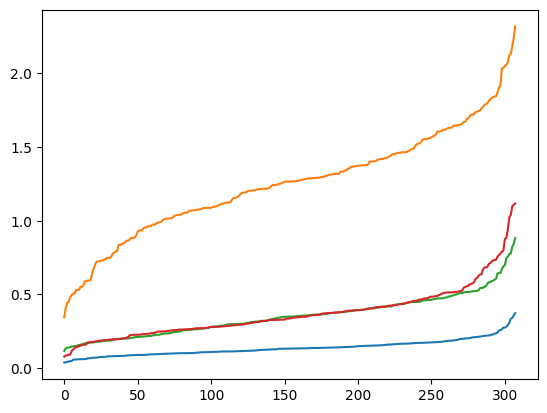

In [7]:
dbscan_best = {}
for name, X in embeddings.items():
    kd = k_distance_plot(X=X)
    plt.plot(kd)
    
    db_best = gridsearch_dbscan(X=X)
    dbscan_best[name] = db_best
    print(f"[{name}] DBSCAN best:", db_best["params"], db_best["metrics"])


In [8]:
kmeans_best = {}
agglom_best = {}

for emb, X in embeddings.items():
    kmeans_best[emb]  = gridsearch_kmeans_params(X, ks=range(2, 6), n_inits=(10, 20))
    agglom_best[emb]  = gridsearch_agglomerative_params(X, ks=range(2, 6), linkages=("ward","complete","average"), metrics=("euclidean","manhattan","cosine"))
    print(f"[{emb}] KMeans best:", kmeans_best[emb]["params"])
    print(f"[{emb}] Agglomerative best:", agglom_best[emb]["params"])

[pca] KMeans best: {'k': 4, 'n_init': 20}
[pca] Agglomerative best: {'k': 4, 'linkage': 'ward', 'metric': 'euclidean'}
[tsne] KMeans best: {'k': 5, 'n_init': 10}
[tsne] Agglomerative best: {'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}
[umap] KMeans best: {'k': 5, 'n_init': 10}
[umap] Agglomerative best: {'k': 5, 'linkage': 'complete', 'metric': 'manhattan'}
[mix] KMeans best: {'k': 2, 'n_init': 10}
[mix] Agglomerative best: {'k': 2, 'linkage': 'complete', 'metric': 'euclidean'}


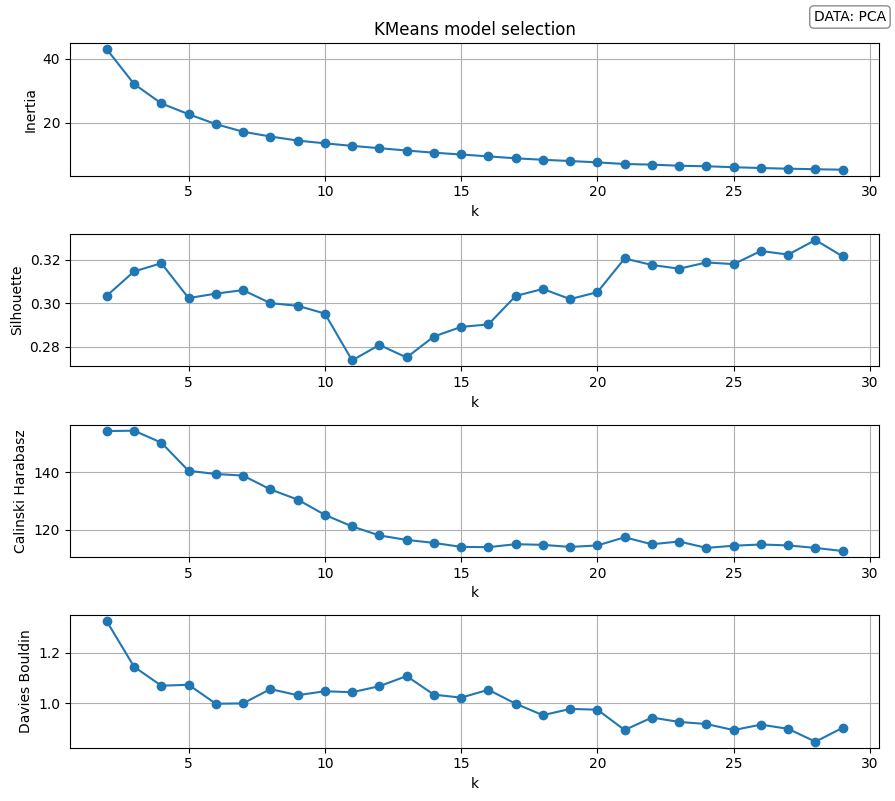

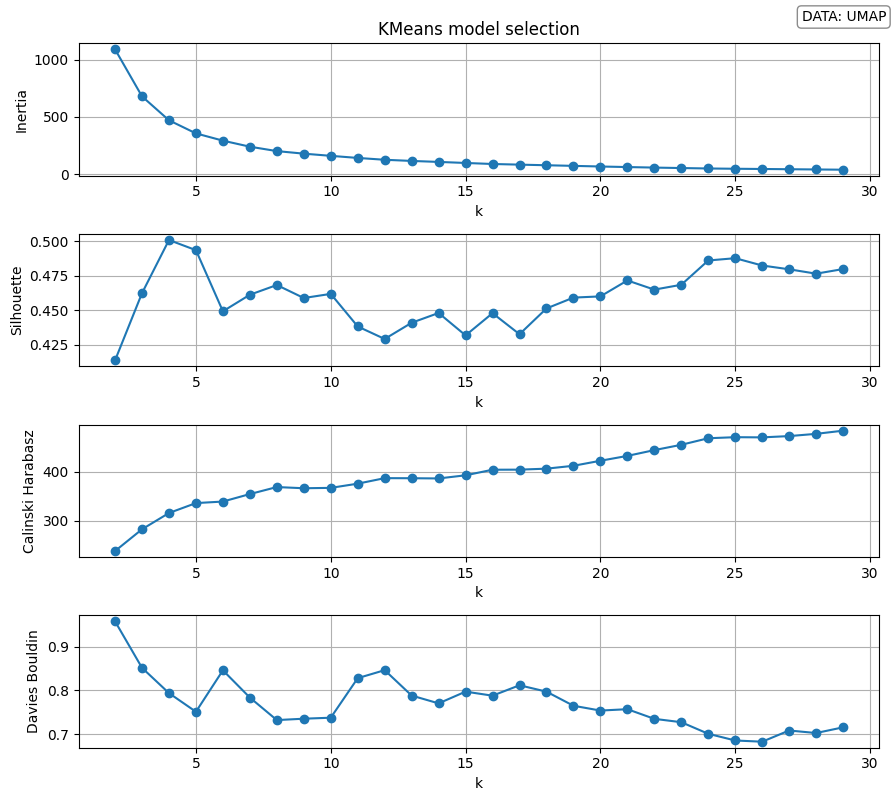

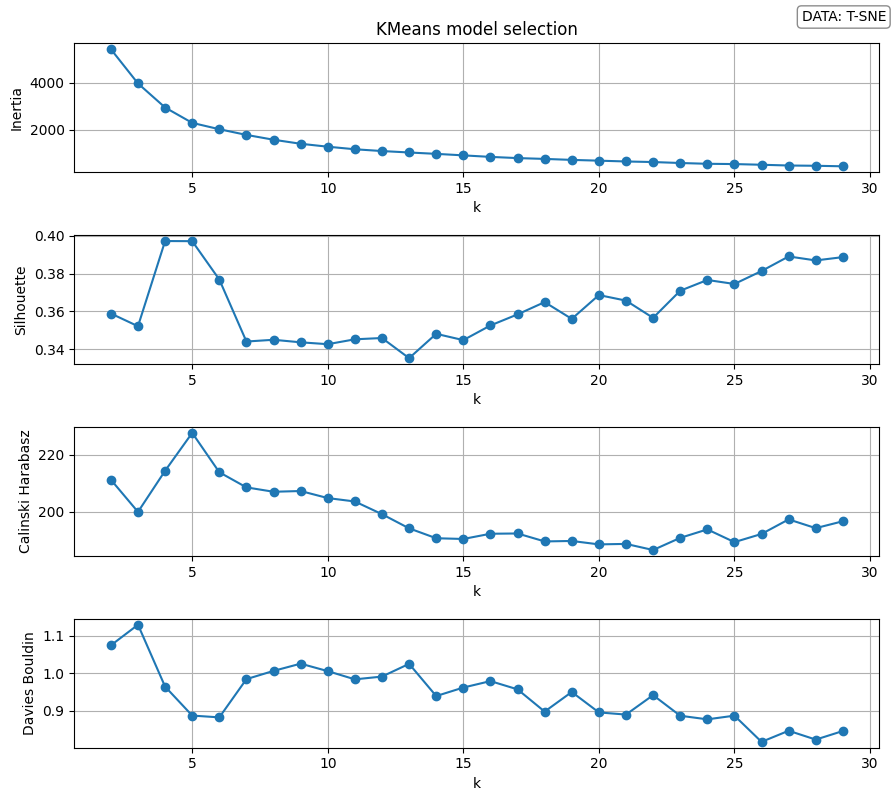

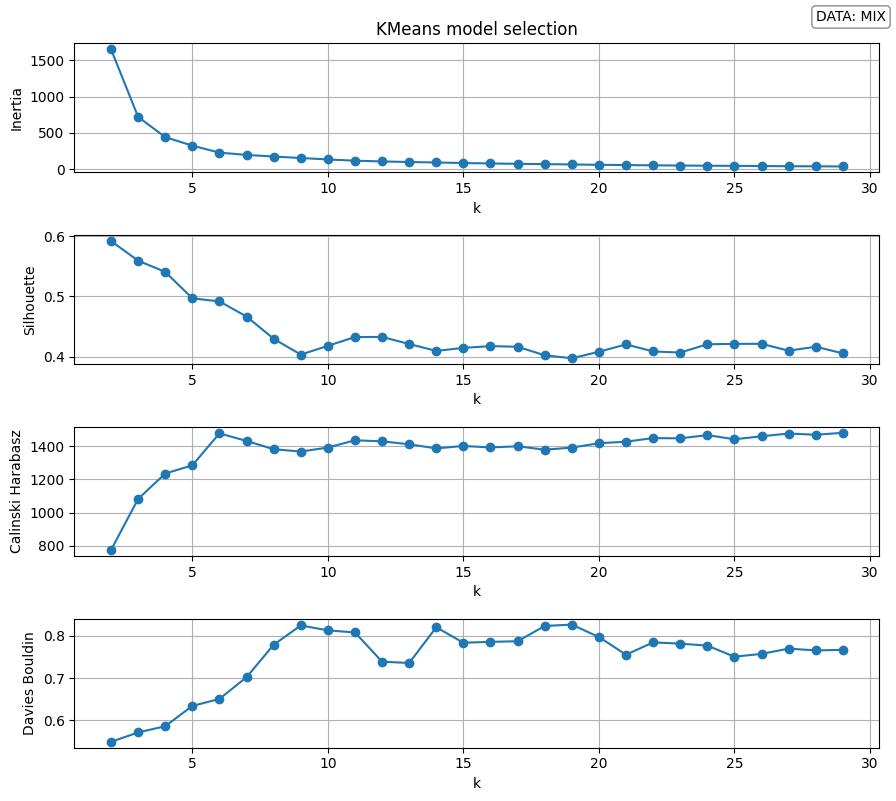


KMeans on PCA
{'inertia': 29, 'silhouette': 28, 'calinski_harabasz': 3, 'davies_bouldin': 28}

KMeans on UMAP
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 29, 'davies_bouldin': 26}

KMeans on T-SNE
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 5, 'davies_bouldin': 26}

KMeans on MIX
{'inertia': 29, 'silhouette': 2, 'calinski_harabasz': 29, 'davies_bouldin': 2}


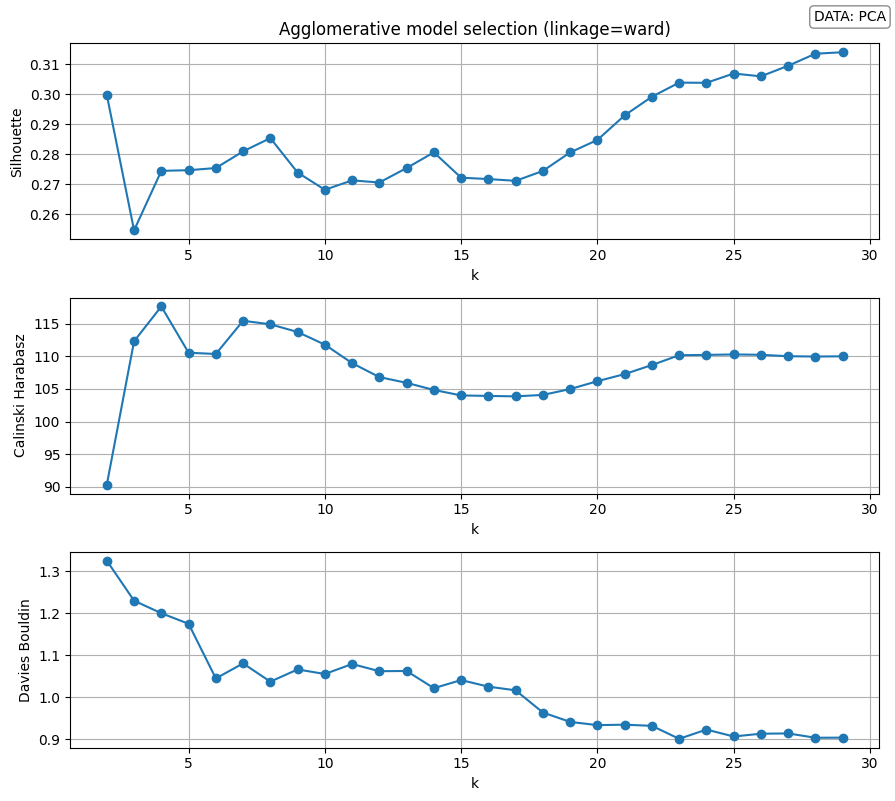

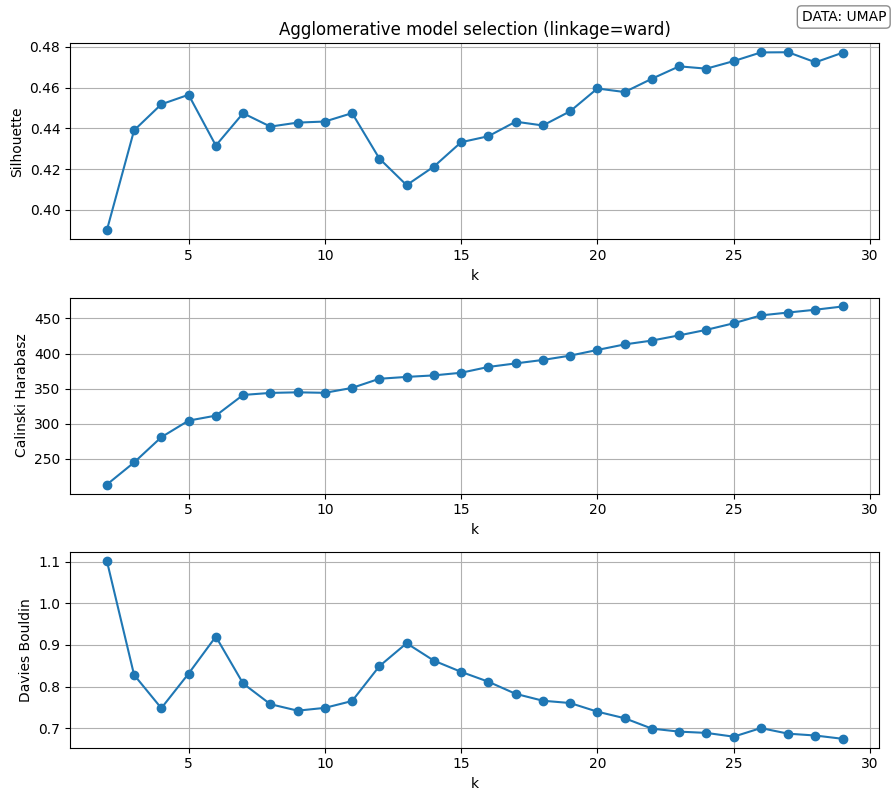

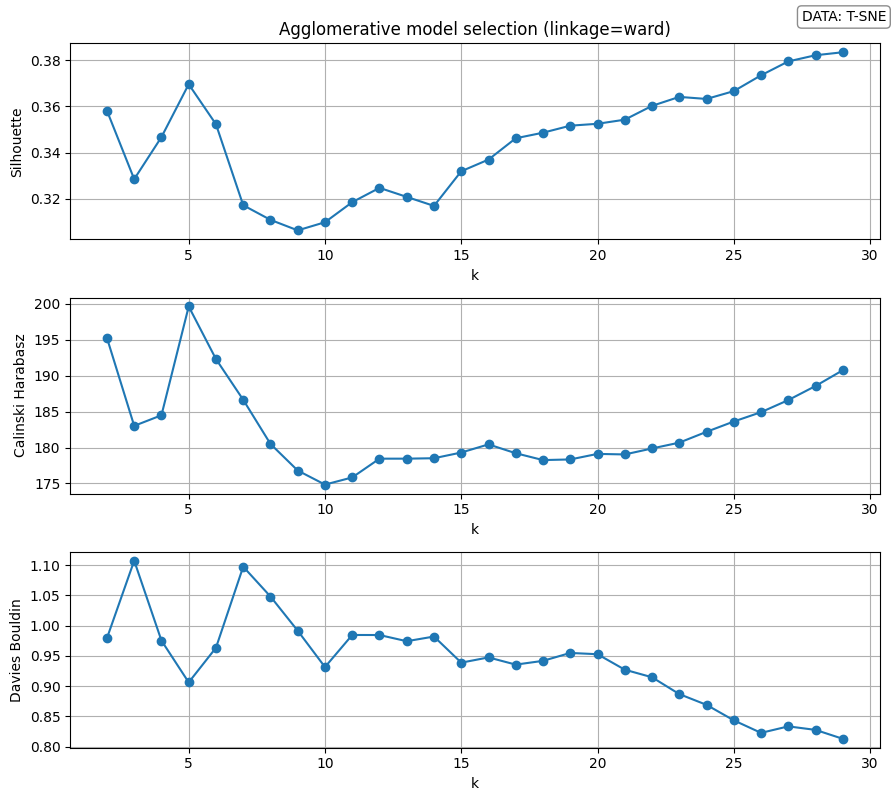

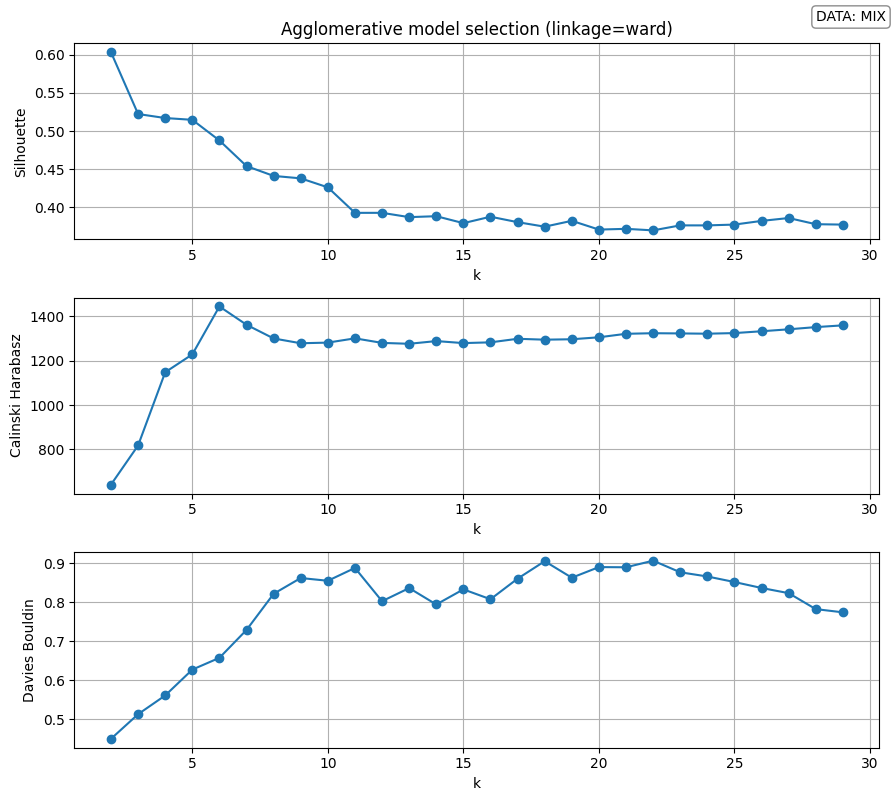


Agglomerative on PCA
{'silhouette': 29, 'calinski_harabasz': 4, 'davies_bouldin': 23}

Agglomerative on UMAP
{'silhouette': 27, 'calinski_harabasz': 29, 'davies_bouldin': 29}

Agglomerative on T-SNE
{'silhouette': 29, 'calinski_harabasz': 5, 'davies_bouldin': 29}

Agglomerative on MIX
{'silhouette': 2, 'calinski_harabasz': 6, 'davies_bouldin': 2}


In [9]:
# KMEANS
kmeans_results = {
    'pca':  select_k_kmeans(X_pca,  k_range=range(2, 30), n_init=50, data_name="PCA"),
    'umap': select_k_kmeans(X_umap, k_range=range(2, 30), n_init=50, data_name="UMAP"),
    't-SNE':select_k_kmeans(X_tsne, k_range=range(2, 30), n_init=50, data_name="t-SNE"),
    'MIX':  select_k_kmeans(X_mix,  k_range=range(2, 30), n_init=50, data_name="MIX"),
}

for name, res in kmeans_results.items():
    print(f"\nKMeans on {name.upper()}")
    print(res.best_by_metric)
    
# AGGLOMERATIVE
agg_results = {
    'pca':  select_k_agglomerative(X_pca,  k_range=range(2, 30), data_name="PCA"),
    'umap': select_k_agglomerative(X_umap, k_range=range(2, 30), data_name="UMAP"),
    't-SNE':select_k_agglomerative(X_tsne, k_range=range(2, 30), data_name="t-SNE"),
    'MIX':  select_k_agglomerative(X_mix,  k_range=range(2, 30), data_name="MIX"),
}

for name, res in agg_results.items():
    print(f"\nAgglomerative on {name.upper()}")
    print(res.best_by_metric)

### Best result overall

In [10]:
board = build_global_leaderboard(embeddings)
ordered = rank_leaderboard(board)

rows = []
for i, r in enumerate(ordered, 1):
    m = r["metrics"]
    rows.append({
        "Rank": i,
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4)
    })

df_leaderboard = pd.DataFrame(rows)

display(df_leaderboard.style
        .background_gradient(subset=["Silhouette"], cmap="Greens")        
        .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")
        .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")
    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})
)

,Rank,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,1,MIX,AGGLOMERATIVE,"{'k': 2, 'linkage': 'complete', 'metric': 'euclidean'}",2,0.6099,693.50,0.4606
1,2,MIX,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",2,0.6079,671.58,0.4539
2,3,MIX,KMEANS,"{'k': 2, 'n_init': 10}",2,0.5918,775.18,0.5492
3,4,UMAP,KMEANS,"{'k': 5, 'n_init': 10}",5,0.4935,335.89,0.7513
4,5,UMAP,AGGLOMERATIVE,"{'k': 5, 'linkage': 'complete', 'metric': 'manhattan'}",5,0.4897,311.13,0.7213
5,6,UMAP,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.4057,174.37,0.9459
6,7,TSNE,KMEANS,"{'k': 5, 'n_init': 10}",5,0.3972,227.57,0.8871
7,8,TSNE,AGGLOMERATIVE,"{'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}",5,0.3733,204.92,0.8816
8,9,PCA,KMEANS,"{'k': 4, 'n_init': 20}",4,0.3176,150.30,1.0678
9,10,PCA,AGGLOMERATIVE,"{'k': 4, 'linkage': 'ward', 'metric': 'euclidean'}",4,0.2744,117.61,1.1999


### Cluster profile of TOP-5

In [11]:
X_orig = X_pre.copy()   # compute profile on original features
interpretation = {}

for i, r in enumerate(ordered[:5], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]
    
    prof, overall = cluster_profile(X_orig, labels)
    interpretation[(emb, algo, i)] = {"profile": prof, "overall": overall, "params": params, "metrics": m}

    print(f"\n=== {i}. {emb} – {algo} ===  \nparams={params}")
    display(prof.style.format("{:.3f}"))


=== 1. MIX – AGGLOMERATIVE ===  
params={'k': 2, 'linkage': 'complete', 'metric': 'euclidean'}



=== 2. MIX – DBSCAN ===  
params={'eps': 0.8, 'min_samples': 3}



=== 3. MIX – KMEANS ===  
params={'k': 2, 'n_init': 10}



=== 4. UMAP – KMEANS ===  
params={'k': 5, 'n_init': 10}



=== 5. UMAP – AGGLOMERATIVE ===  
params={'k': 5, 'linkage': 'complete', 'metric': 'manhattan'}


### SMD tables for the top-3 entries

In [12]:
topK = 3
top_smd_tables = {}

for i, r in enumerate(ordered[:topK], 1):
    smd_df = compute_smds(X_orig, r["labels"])
    top_smd_tables[(i, r["emb"].upper(), r["algo"].upper())] = smd_df

for rank in range(1, topK+1):
    entry = ordered[rank-1]
    key = (rank, entry['emb'].upper(), entry['algo'].upper())
    smd_df = top_smd_tables[key]
    tbl = top_union_smd_table(smd_df, top_n=8, feature_order="max")
    display(tbl.style.format("{:.3f}").set_caption(f"|SMD| cluster — [{rank}] {key[1]} – {key[2]}"))


,Cluster 0,Cluster 1
Feature,,
time,0.501,1.234
serum_creatinine,0.173,0.425
age,0.128,0.316
serum_sodium,0.069,0.170
ejection_fraction,0.006,0.014


,Cluster 0,Cluster 1
Feature,,
time,0.482,1.244
serum_creatinine,0.160,0.414
age,0.114,0.293
serum_sodium,0.062,0.161
ejection_fraction,0.021,0.055


,Cluster 0,Cluster 1
Feature,,
time,0.983,0.709
serum_creatinine,0.366,0.264
age,0.218,0.157
serum_sodium,0.101,0.073
ejection_fraction,0.000,0.000


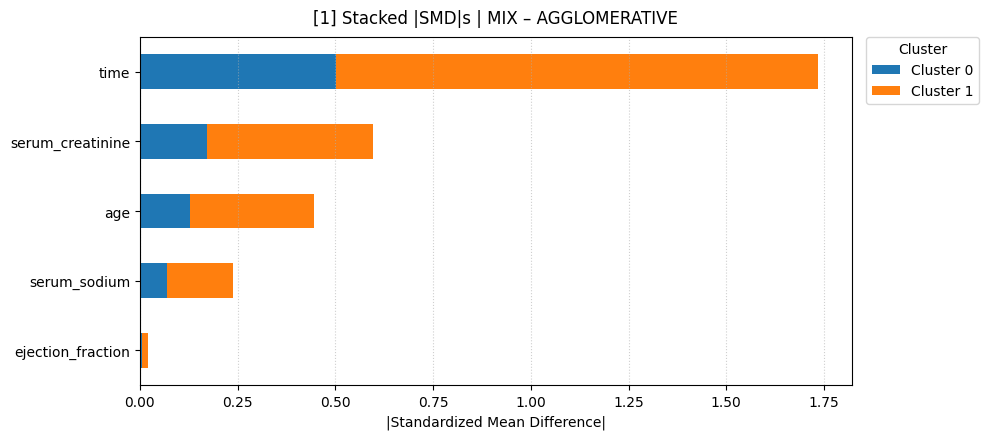

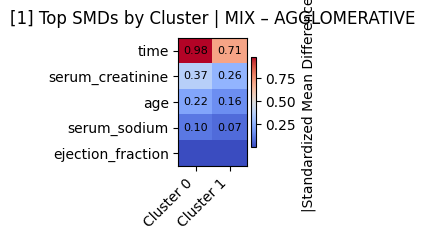

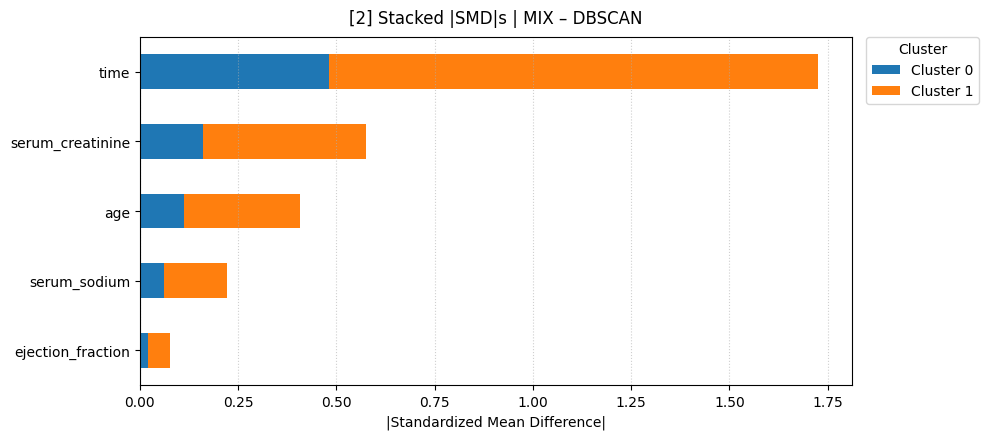

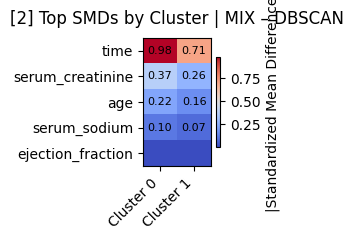

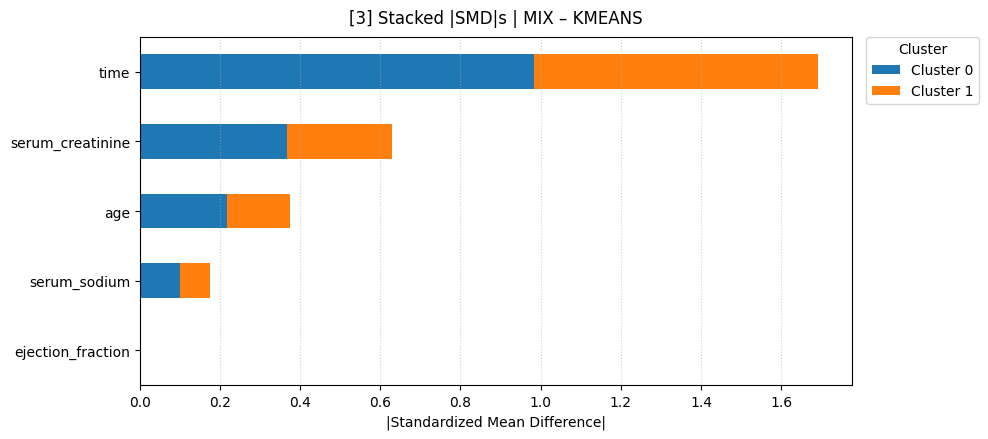

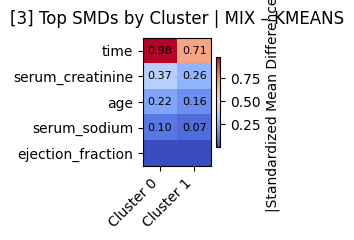

In [13]:
for rank in range(1, topK + 1):
    entry = ordered[rank - 1]
    key = (rank, entry['emb'].upper(), entry['algo'].upper())

    plot_smd_stacked_bars(top_smd_tables[key], title=f"[{rank}] Stacked |SMD|s | {key[1]} – {key[2]}",)
    plot_smd_heatmap(smd_df, title=f"[{rank}] Top SMDs by Cluster | {key[1]} – {key[2]}")


In [14]:
for rank in range(1, topK + 1):
    entry = ordered[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"].lower()
    labels = entry["labels"]

    title = f"[{rank}] {emb.upper()} – {algo}  params={params} | Clusters vs DEATH_EVENT"
    plot_clusters_target_3d(embeddings[emb], labels, y, title=title)


Interesting results:
 - [1] Plot: *Cluster 1* constitutes almost only people who did not die.
- [3] Plot: *Cluster 3* constitutes almost only people who did not die. There are also two groups by mortality and survival.

## Preprocessed dataset

In [15]:
params_db = {"eps": 0.3, "min_samples": 3}
params_km = {"n_clusters": 4, "n_init": 50}
params_ag = {"n_clusters": 4, "linkage": "ward", "metric": "euclidean"}

db = DBSCAN(eps=params_db["eps"], min_samples=params_db["min_samples"])
km = KMeans(n_clusters=params_km["n_clusters"], n_init=params_km["n_init"])
ag = AgglomerativeClustering(n_clusters=params_ag["n_clusters"], linkage=params_ag["linkage"])

labels_db = db.fit_predict(X_pre)
labels_km = km.fit_predict(X_pre)
labels_ag = ag.fit_predict(X_pre)

## Best params finder

In [16]:
db_best   = gridsearch_dbscan(X=X_pre)
km_best   = gridsearch_kmeans_params(X_pre, ks=range(2, 6), n_inits=(25, 50))
ag_best   = gridsearch_agglomerative_params(X_pre, ks=range(2, 12), linkages=("ward","complete","average"), metrics=("euclidean","manhattan","cosine"))

params_db = db_best["params"]
params_km = km_best["params"]
params_ag = ag_best["params"]

print("DBSCAN(best on PRE):", params_db)
print("KMeans(best on PRE):", params_km)
print("Agglomerative(best on PRE):", params_ag)

DBSCAN(best on PRE): {'eps': 0.3, 'min_samples': 3}
KMeans(best on PRE): {'k': 4, 'n_init': 50}
Agglomerative(best on PRE): {'k': 4, 'linkage': 'ward', 'metric': 'euclidean'}


## Dimensionality Reduction

In [17]:
pca_pre  = PCA(n_components=3).fit_transform(X_pre)
tsne_pre = TSNE(n_components=3).fit_transform(X_pre)
umap_pre = umap.UMAP(n_components=3).fit_transform(X_pre)
mix_pre  = np.c_[pca_pre[:, 0], pca_pre[:, 1], umap_pre[:, 0]]

embeddings_dimred = {
    "PCA":  pca_pre,
    "t-SNE": tsne_pre,
    "UMAP": umap_pre,
    "MIX":  mix_pre,
}

KeyboardInterrupt: 

In [ ]:
rows_cd: list[dict] = []
for name, X in embeddings_dimred.items():
    scores_db = show_scores(f"DBSCAN on {name}", X, labels_db, y)
    scores_km = show_scores(f"KMeans on {name}", X, labels_km, y)
    scores_ag = show_scores(f"Agglomerative on {name}",  X, labels_ag, y)

    append_result(rows_cd, f"DBSCAN on {name}", "dbscan", labels_db, scores_db["internal"], scores_db["external"], params=params_db) 
    append_result(rows_cd, f"KMeans on {name}", "kmeans", labels_km, scores_km["internal"], scores_km["external"], params=params_km) 
    append_result(rows_cd, f"Agglomerative on {name}", "agglomerative", labels_ag, scores_ag["internal"], scores_ag["external"], params=params_ag)

    show(plot_3d(X3d=X, y=labels_db, algorithm=f"DBSCAN on PRE {name}", target_name="cluster", data_name=name))
    show(plot_3d(X3d=X, y=labels_km, algorithm=f"KMeans on PRE {name}", target_name="cluster", data_name=name))
    show(plot_3d(X3d=X, y=labels_ag, algorithm=f"Agglomerative on PRE {name}", target_name="cluster", data_name=name))


[DBSCAN on PCA] -> clusters=3, noise=2.9%, sil=-0.07795541025893706, CH=4.693394269122046, DB=3.2539587138200385, ARI=0.016102190867454486, NMI=0.023963319671802562, V=0.023963319671802562
[KMeans on PCA] -> clusters=4, noise=0.0%, sil=0.3083295226077398, CH=145.19465826645347, DB=1.0835021582220883, ARI=0.16128378758901413, NMI=0.17169225148109854, V=0.17169225148109854
[Agglomerative on PCA] -> clusters=4, noise=0.0%, sil=0.2896773276562372, CH=133.09752703466083, DB=1.1017157507432882, ARI=0.12747242554528523, NMI=0.1462001150409351, V=0.1462001150409351


[DBSCAN on t-SNE] -> clusters=3, noise=2.9%, sil=-0.20352980494499207, CH=2.5665128231048584, DB=3.5091146771788555, ARI=0.016102190867454486, NMI=0.023963319671802562, V=0.023963319671802562
[KMeans on t-SNE] -> clusters=4, noise=0.0%, sil=0.34783995151519775, CH=177.53309631347656, DB=1.0904744995315239, ARI=0.16128378758901413, NMI=0.17169225148109854, V=0.17169225148109854
[Agglomerative on t-SNE] -> clusters=4, noise=0.0%, sil=0.36898937821388245, CH=193.72650146484375, DB=1.0031978361169842, ARI=0.12747242554528523, NMI=0.1462001150409351, V=0.1462001150409351


[DBSCAN on UMAP] -> clusters=3, noise=2.9%, sil=-0.30551040172576904, CH=1.8836971521377563, DB=2.715603953850514, ARI=0.016102190867454486, NMI=0.023963319671802562, V=0.023963319671802562
[KMeans on UMAP] -> clusters=4, noise=0.0%, sil=0.4357638657093048, CH=259.040283203125, DB=0.8951543392998423, ARI=0.16128378758901413, NMI=0.17169225148109854, V=0.17169225148109854
[Agglomerative on UMAP] -> clusters=4, noise=0.0%, sil=0.4836621880531311, CH=299.1220397949219, DB=0.7916138567054474, ARI=0.12747242554528523, NMI=0.1462001150409351, V=0.1462001150409351


[DBSCAN on MIX] -> clusters=3, noise=2.9%, sil=-0.43918690079422407, CH=0.8624835377911277, DB=5.201887323803445, ARI=0.016102190867454486, NMI=0.023963319671802562, V=0.023963319671802562
[KMeans on MIX] -> clusters=4, noise=0.0%, sil=0.17731660770801758, CH=173.83592055123836, DB=1.7203684716365046, ARI=0.16128378758901413, NMI=0.17169225148109854, V=0.17169225148109854
[Agglomerative on MIX] -> clusters=4, noise=0.0%, sil=0.17878964568294775, CH=199.5685913976448, DB=1.459360106443957, ARI=0.12747242554528523, NMI=0.1462001150409351, V=0.1462001150409351


### Best result overall

In [ ]:
board = build_global_leaderboard(embeddings_dimred)
ordered = rank_leaderboard(board)

rows = []
for i, r in enumerate(ordered, 1):
    m = r.get("metrics", {})
    rows.append({
        "Rank": i,
        "Embedding": str(r.get("emb", "")).upper(),
        "Algorithm": str(r.get("algo", "")).upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4)
    })

df_leaderboard = pd.DataFrame(rows)

display(df_leaderboard.style
        .background_gradient(subset=["Silhouette"], cmap="Greens")        
        .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")
        .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")
    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})
)

,Rank,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,1,MIX,KMEANS,"{'k': 2, 'n_init': 10}",2,0.5438,573.82,0.6662
1,2,MIX,AGGLOMERATIVE,"{'k': 2, 'linkage': 'average', 'metric': 'manhattan'}",2,0.5429,570.72,0.6679
2,3,UMAP,KMEANS,"{'k': 5, 'n_init': 10}",5,0.5151,354.64,0.7185
3,4,UMAP,AGGLOMERATIVE,"{'k': 5, 'linkage': 'average', 'metric': 'euclidean'}",5,0.4989,341.30,0.7319
4,5,MIX,DBSCAN,"{'eps': 0.3, 'min_samples': 10}",2,0.4088,64.48,1.1619
5,6,UMAP,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.3986,174.69,0.9586
6,7,T-SNE,KMEANS,"{'k': 5, 'n_init': 10}",5,0.3972,227.57,0.8871
7,8,T-SNE,AGGLOMERATIVE,"{'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}",5,0.3733,204.92,0.8816
8,9,PCA,KMEANS,"{'k': 4, 'n_init': 20}",4,0.3176,150.30,1.0678
9,10,PCA,AGGLOMERATIVE,"{'k': 4, 'linkage': 'ward', 'metric': 'euclidean'}",4,0.2744,117.61,1.1999


### Cluster profile of TOP-5

In [ ]:
X_orig = X_pre.copy()   # compute profile on original features
interpretation = {}

for i, r in enumerate(ordered[:5], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]
    
    prof, overall = cluster_profile(X_orig, labels)
    interpretation[(emb, algo, i)] = {"profile": prof, "overall": overall, "params": params, "metrics": m}

    print(f"\n=== {i}. {emb} – {algo} ===  \nparams={params}")
    display(prof.style.format("{:.3f}"))


=== 1. MIX – KMEANS ===  
params={'k': 2, 'n_init': 10}



=== 2. MIX – AGGLOMERATIVE ===  
params={'k': 2, 'linkage': 'average', 'metric': 'manhattan'}



=== 3. UMAP – KMEANS ===  
params={'k': 5, 'n_init': 10}



=== 4. UMAP – AGGLOMERATIVE ===  
params={'k': 5, 'linkage': 'average', 'metric': 'euclidean'}



=== 5. MIX – DBSCAN ===  
params={'eps': 0.3, 'min_samples': 10}


### SMD tables for the top-3 entries

In [ ]:
topK = 3
top_smd_tables = {}

for i, r in enumerate(ordered[:topK], 1):
    smd_df = compute_smds(X_orig, r["labels"])
    top_smd_tables[(i, r["emb"].upper(), r["algo"].upper())] = smd_df

for rank in range(1, topK+1):
    entry = ordered[rank-1]
    key = (rank, entry['emb'].upper(), entry['algo'].upper())
    smd_df = top_smd_tables[key]
    tbl = top_union_smd_table(smd_df, top_n=8, feature_order="max")
    display(tbl.style.format("{:.3f}").set_caption(f"|SMD| cluster — [{rank}] {key[1]} – {key[2]}"))


,Cluster 0,Cluster 1
Feature,,
serum_creatinine,0.523,0.819
serum_sodium,0.213,0.334
age,0.158,0.247
ejection_fraction,0.108,0.170
time,0.082,0.129


,Cluster 0,Cluster 1
Feature,,
serum_creatinine,0.803,0.513
serum_sodium,0.319,0.203
age,0.264,0.169
ejection_fraction,0.174,0.111
time,0.145,0.093


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Feature,,,,,
serum_creatinine,0.417,1.568,0.695,0.321,0.180
ejection_fraction,0.101,0.368,0.127,1.293,1.013
time,1.213,0.458,0.372,0.498,1.095
age,0.243,0.220,0.492,0.787,0.093
serum_sodium,0.240,0.786,0.044,0.303,0.511


In [ ]:
for rank in range(1, topK + 1):
    entry = ordered[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"].lower()
    labels = entry["labels"]

    title = f"[{rank}] {emb.upper()} – {algo}  params={params} | Clusters vs DEATH_EVENT"
    plot_clusters_target_3d(embeddings[emb], labels, y, title=title)
